# Итоговый проект по Data Science  
## Анализ гетерогенности терапевтического отклика на антидепрессанты

**Формат:** Google Colab / Jupyter Notebook  
**Тип проекта:** анализ данных клинического исследованиях с индивидуальными данными пациентов
**Данные:** открытый longitudinal clinical trial dataset `rbmi::antidepressant_data`  
**Основные методы:** preprocessing, EDA, investigator-level adjustment, LMM-style model, Gaussian Mixture Models with random starts, quantile regression, bootstrap validation, sensitivity analysis.

---

## Паспорт проекта

| Пункт | Описание |
|---|---|
| Программа | Специалист по Data Science |
| Тип задачи | Анализ табличных клинических данных |
| Область | Clinical tabular data / depression treatment response |
| Основной вопрос | Есть ли признаки неоднородности терапевтического отклика, и лучше ли она описывается дискретными латентными подгруппами или непрерывным изменением эффекта вдоль распределения? |
| Научная мотивация | Дискуссия между FMM-интерпретацией Stone et al. и QTE-интерпретацией Meyerson et al. |
| Основной таргет | `percentage_response = (baseline_score - endpoint_score) / baseline_score` |
| Sensitivity target | `absolute_response = baseline_score - endpoint_score` |
| Primary baseline threshold | `BASVAL >= 14` |
| Группирующая структура | `POOLINV`, pooled investigator |
| Модели | Adjustment model, FMM, quantile regression |
| Валидация | Bootstrap, BIC/AIC, sensitivity analysis, pinball loss, pseudo R² |
| Ограничение | Используется один открытый датасет; это не IPD meta-analysis |

---


---

## Краткая идея проекта

Средний эффект лечения может скрывать неоднородность индивидуального отклика. Поэтому в проекте сравниваются две интерпретации:

1. **Латентные подгруппы отклика**: распределение ответов можно описать несколькими скрытыми компонентами через Finite Mixture Models.
2. **Непрерывная неоднородность**: эффект лечения меняется вдоль распределения ответов; это проверяется через квантильную регресию.

Эти две модели отражают реальную научную дискуссию в литературе об антидепрессантах. Stone et al. предложили FMM-интерпретацию латентных групп ответа, а Meyerson et al. предложили QTE-интерпретацию более распределённого эффекта лечения.

Ключевой итог будет в сравнении того, какая интерпретация лучше и устойчивее описывает структуру индивидуального отклика в доступном открытом датасете.

# 1. Постановка задачи

## 1.1. Ценность задачи

В мета анализах клинических исследований антидепрессантов часто оценивают средний эффект лечения при помощи эффекта Коэна Д или стандартизированной разницы средних. Но средний эффект может быть недостаточным для понимания того, как лечение действует на разных пациентов. Например, одинаковый средний эффект может возникнуть в двух разных ситуациях:

- лечение немного помогает почти всем;
- лечение сильно помогает небольшой части пациентов и почти не помогает остальным.

Для принятия решений в медицине и для будущей персонализации лечения важно понимать не только средний эффект, но и форму распределения индивидуального отклика.

## 1.2. Научная дискуссия, из которой вырос проект

Проект основан на научной дискусии в недавних мета анализах.

**Stone et al., BMJ 2022** проанализировали индивидуальные данные 232 плацебо контролируемых исследований, поданных в FDA, и использовали **finite mixture models**. Их интерпретация: распределение ответа лучше описывается тремя компонентами —Большим, Не специфичным и Минимальным ответом. В этой логике средний эффект антидепрессантов может возникать потому, что активное лечение повышает вероятность попадания в группу большого ответа.  
Источник: [Stone et al., BMJ 2022](https://www.bmj.com/content/378/bmj-2021-067606)

**Meyerson et al., JAMA Network Open 2023** использовали те же клинические FDA данные, но другой статистический язык — **quantile treatment effects**. Они ограничили анализ участниками с первичным баллом по HAMD ≥ 20 и показали, что распределение ответов в группе лечения была лучше плацебо на всех изученных квантилях, с максимальным разделением около 55-го квантиля. Их интерпретация ближе к непрерывной неоднородности эффекта, а не к жёстким латентным классам.  
Источник: [Meyerson et al., JAMA Network Open 2023](https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2805805)

Дополнительно **Xu et al., Journal of Clinical Epidemiology 2025** попытались проверить тримодальную FMM-интерпретацию на STAR*D и не смогли воспроизвести компоненты Stone et al.
Источник: [Xu et al., Journal of Clinical Epidemiology 2025](https://www.jclinepi.com/article/S0895-4356(25)00276-8/fulltext)

Таким образом, основная исследовательская идея проекта:

> Проверить на открытом датасете, выглядит ли гетерогенность ответов скорее как устойчивые латентные подгруппы с тримодальным ответом или как непрерывное изменение эффекта вдоль распределения.

## 1.3. Цель проекта

Построить воспроизводимый пайплайн для анализа гетерогенности терапевтического отклика на антидепрессанты в открытом клиническом датасете.

## 1.4. Задачи проекта

1. Загрузить открытый лонгитюдный датасет клинического исследования.
2. Привести данные к формату конечного балла пациента.
3. Рассчитать два таргета отклика:
   - процентный ответ(percentage response);
   - обсолютный ответ(absolute response).
4. Провести EDA и проверить структуру данных.
5. Учесть ковариаты, такие как изначальную тяжесть(baseline severity) и гетерогеность исследовательского центра через переменную `POOLINV`.
6. Проверить гипотезу латентных подгрупп через Gaussian Mixture Models.
7. Проверить непрерывную неоднородность treatment effect через квантильную регресию
8. Провести бутстреп и анализ чувствительности.
9. Сформулировать интерпретируемый итог для защиты.

## 1.5. Что НЕ утверждается в проекте

Этот проект не утверждает, что найденные статистические компоненты автоматически являются биологическими фенотипами. FMM используется как исследовательский инструмент.

# 2. Дизайн исследования и методология

## 2.1. Формат исследования

Итоговый проект выполнен как анализ индивидуальных данных пациентов из одного открытого лонгитюдного датасета с повторными измеренями.

Дополнительные открытые данные КИ по антидепрессантам не удалось получить в сроки проекта, поэтому работа не позиционируется как мета-анализ.



## 2.2. Роль переменной `POOLINV`

В исходном датасете присутствует переменная `POOLINV`. В документации
(https://openpharma.github.io/rbmi/main/reference/antidepressant_data.html) она описана как pooled investigator.

В рамках проекта `POOLINV` трактуется как анонимизированный идентификатор уровня исследовательской структуры внутри одного клинического исследования. Это группирующая переменная, содержащаяся в исходной таблице.

Учет `POOLINV` важен, потому что пациенты, относящиеся к одной группе, могут быть похожи между собой по условиям набора, процедурам оценки и исходной тяжести заболевания. Если эту структуру не учитывать, часть различий между исследовательскими группами может ошибочно интерпретироваться как индивидуальная гетерогенность терапевтического отклика.

В проекте `POOLINV` используется для трех целей:

1. диагностика внутренней структуры датасета;
2. центрирование первичной тяжести внутри исследовательских-групп;
3. скоректированная модель через random-intercept или фиксированным эффектом `C(POOLINV)`.

## 2.3. Бейслайн центрирование

В исследованиях на индивидуальных данных пациентов важно разделять индивидуальные и групповые эффекты ковариат. В работе Stone et al. использовалось центрирование ковариат на уровне пациента вокруг среднего значения исследования, чтобы снизить риск экологической ошибки во взаимодействии ковариат с исходами. Методологически это связано с подходом Burke et al
Источники: [Stone et al., BMJ 2022](https://www.bmj.com/content/378/bmj-2021-067606), [Burke et al., Statistics in Medicine 2017](https://doi.org/10.1002/sim.7141)

В данном проекте используется один датасет, поэтому аналогичная идея применяется не на уровне разных исследований, а на уровне переменной "POOLINV". Для исходной тяжести депрессии рассчитывается:

```text
BASVAL_centered = BASVAL - mean(BASVAL внутри POOLINV)
```

Такой вариант позволяет сравнивать пациента не только с общей выборкой, а с пациентами внутри той же исследовательской группы. Это снижает риск того, что различия между группами будут приняты за индивидуальные различия в отклике.

## 2.4. Порог тяжести и поправка на исследовательскую группу

Порог тяжести (baseline cut-off) и учет "POOLINV" решают разные методологические задачи.

"BASVAL >= 14" используется как порог отсечения по тяжести заболевания для включения пациентов в основной анализ. Этот порог выбран не произвольно: в работ еXu et -анализе STAR*D, посвященном проверке выводов Stone et al., основной анализ также включал пациентов с HDRS ≥ 14, авторы отмечают что этот порог является золотым стадартом.
Источник: [Xu et al., Journal of Clinical Epidemiology 2025](https://www.jclinepi.com/article/S0895-4356(25)00276-8/fulltext)

Практическая роль порога в проекте — уменьшить нестабильность переменной процентного ответа "percentage_response" у пациентов с очень низкой исходной тяжестью. При низком изначальном бале даже небольшое абсолютное изменение может давать непропорционально большой процентный отклик.


- порог тяжести повышает стабильность целевой переменной percentage response;
- POOLINV поправка учитывает внутреннюю группировку пациентов.

## 2.5. Квантильная регрессия как практическая адаптация QTE подхода

 Meyerson et al. предложили интерпретацию ответов на терапию АД через "quantile treatment effects"- разницей в распределениях ответов между плацебо и активной терапией на разных квантилях.

В данном проекте вместо полного QTE используется квантильная регрессия,потому что она позволяет включать индивидуальные ковариаты.

Спецификация модели

```text
ответ ~ терапия + BASVAL_centered + gender_female
```

В модели используются все доступные переменные, подходящие для поправки:

- treatment — вещество против плацебо;
- BASVAL_centered — исходная тяжесть депрессии, центрированная внутри POOLINV;
- gender_female — доступная демографическая ковариата.

Переменные HAMDTL17,CHANGE и PGIIMP не включаются потому что они связаны c конечным исходом, их использование в качестве предикторов могло бы привести к утечке данных (data leakage)

Дополнительно проверяется чувствительность

```text
response ~ treatment + BASVAL_centered + gender_female + C(POOLINV)
```

Она показывает сохраняется ли профиль эффекта ткерапии при явном учете исследовательской группы.

## 2.6. Spline и ANCOVA как проверка чувствительности.

В Stone et al. для непрерывных ковариат использовались "multivariable adaptive regression splines", чтобы учесть возможные нелинейные связи первичной тяжести, возраста и других ковариат с исходом. В данном проекте первичная модель оставлена более простой, потому что выборка после фильтрации небольшая, а набор доступных ковариат ограничен.

Чтобы проверить устойчивость результатов в анализ чуствительности добавлена spline-спецификация для первичной тяжести:

```text
response ~ treatment + spline(BASVAL_centered) + gender_female
```

Также добавлена ANCOVA-style endpoint модель:

```text
endpoint_score ~ treatment + baseline severity + gender + POOLINV
```

Эта проверка важна,потому что первичная тяжесть может механически коррелировать с измненением балла от начала лечения.

# 3. Установка библиотек и конфигурация

Эта тетрадь рассчитана на запуск в Google Colab. GPU/TPU не требуется: используемые библиотеки (`pandas`, `statsmodels`, `sklearn`) в основном работают на CPU.

In [1]:
!pip install -q pyreadr requests pandas numpy scipy scikit-learn statsmodels matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 17.0 MB/s eta 0:00:00


In [9]:
import io
import re
import tarfile
import time
import warnings
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import pyreadr
import requests

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.mixture import GaussianMixture

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from patsy import bs
from typing import Optional

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# настройки первичного анализа
PRIMARY_BASELINE_CUTOFF = 14
SENSITIVITY_CUTOFFS = [None, 14, 18, 20, 24]

# настройки квантильной регресии
QUANTILES = np.round(np.arange(0.05, 1.00, 0.05), 2)

# настройки FFM и К по примеру Stone
FMM_COMPONENTS = range(1, 6)
FMM_COVARIANCE_TYPES_MAIN = ("full", "tied", "diag", "spherical")
FMM_RANDOM_STARTS_MAIN = 100

#Настройки бутстрапа
# 150 из за ограниченных возможностей колаба
FMM_BOOTSTRAP_ITERATIONS = 150
FMM_COVARIANCE_TYPES_BOOTSTRAP = ("full", "tied")
FMM_RANDOM_STARTS_BOOTSTRAP = 100

# Interpretation rule for mixture components
MIN_COMPONENT_WEIGHT = 0.05

GMM_DISPLAY_COLUMNS = [
    "n_components",
    "covariance_type",
    "bic",
    "aic",
    "converged_runs",
    "best_seed",
]

# настройки хранения
DATA_DIR = Path("data")
FIG_DIR = Path("reports/figures")
RESULTS_DIR = Path("reports/results")

for directory in [DATA_DIR, FIG_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# настройки для графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns",120)
pd.set_option("display.width",160)

print("Project configuration loaded.")
print(f"Primary baseline cut-off: BASVAL >= {PRIMARY_BASELINE_CUTOFF}")
print(f"Bootstrap iterations: {FMM_BOOTSTRAP_ITERATIONS}")
print(f"GMM random starts: {FMM_RANDOM_STARTS_MAIN}")

Project configuration loaded.
Primary baseline cut-off: BASVAL >= 14
Bootstrap iterations: 150
GMM random starts: 100


# 4. Загрузка данных

## 4.1. Источник данных

Используется открытый датасет `antidepressant_data` из R-пакета `rbmi`.

Датасет содержит longitudinal clinical trial data:

- `PATIENT` — идентификатор пациента;
- `THERAPY` — DRUG / PLACEBO;
- `BASVAL` — baseline HAMD17;
- `HAMDTL17` — HAMD17 на визите;
- `CHANGE` — изменение HAMD17;
- `VISIT` — номер визита;
- `POOLINV` — investigator / site-level grouping variable;
- `GENDER` — пол пациента.

In [7]:
csv_path = Path("antidepressant_data.csv")

if not csv_path.exists():
#ссылка на готовый файл данных
    url = "https://raw.githubusercontent.com/cran/rbmi/master/data/antidepressant_data.rda"
    rda_path = "temp.rda"
    urllib.request.urlretrieve(url, rda_path)
    pyreadr.read_r(rda_path)["antidepressant_data"].to_csv(csv_path, index=False)

df_raw = pd.read_csv(csv_path)
# проверяем
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
display(df_raw.head())


Shape: (608, 11)
Columns: ['PATIENT', 'HAMATOTL', 'PGIIMP', 'RELDAYS', 'VISIT', 'THERAPY', 'GENDER', 'POOLINV', 'BASVAL', 'HAMDTL17', 'CHANGE']


,PATIENT,HAMATOTL,PGIIMP,RELDAYS,VISIT,THERAPY,GENDER,POOLINV,BASVAL,HAMDTL17,CHANGE
0,1503,21.0,2.0,7.0,4,DRUG,F,6,32.0,21.0,-11.0
1,1503,19.0,2.0,14.0,5,DRUG,F,6,32.0,20.0,-12.0
2,1503,21.0,3.0,28.0,6,DRUG,F,6,32.0,19.0,-13.0
3,1503,17.0,4.0,42.0,7,DRUG,F,6,32.0,17.0,-15.0
4,1507,18.0,3.0,7.0,4,PLACEBO,F,6,14.0,11.0,-3.0


## Промежуточный вывод

Данные успешно загружены, количество строк больше количества пациентов, потому что у нас в датасете повторные измерения в течении 7 недель

# 5. Функции проекта

В этом разделе собраны функции для обработки данных, диагностики, моделирования, валидации и сохранения результатов. Такой подход улучшает читаемость кода и соответствует требованию структурированности.

In [26]:
# ================= вспомогательные =================

def save_fig(fn: str) -> None:
    plt.tight_layout()
    plt.savefig(FIG_DIR / fn, dpi=200, bbox_inches="tight")
    print(f"Saved: {FIG_DIR / fn}")


def finalize_plot(title: str, xlabel: str, ylabel: str | None = None,
                  figsize: tuple = (8, 5), filename: Optional[str] = None) -> None:
    plt.gcf().set_size_inches(figsize)
    plt.title(title); plt.xlabel(xlabel)
    if ylabel: plt.ylabel(ylabel)
    if plt.gca().get_legend_handles_labels()[0]: plt.legend()
    if filename: save_fig(filename)
    plt.show()


def pinball_loss(y_true, y_pred, q: float) -> float:
    r = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.maximum(q * r, (q - 1) * r)))


def add_fdr(df: pd.DataFrame, p_col: str = "p_value") -> pd.DataFrame:
    df = df.copy()
    mask = df[p_col].notna()
    df = df.assign(p_value_fdr_bh=np.nan, significant_fdr_0_05=False)
    if mask.any():
        rej, corr, _, _ = multipletests(df.loc[mask, p_col].values, alpha=0.05, method="fdr_bh")
        df.loc[mask, ["p_value_fdr_bh", "significant_fdr_0_05"]] = np.column_stack([corr, rej])
    return df


# ================= ДАННЫЕ =================

def prepare_data(data: pd.DataFrame) -> pd.DataFrame:
    df = data.rename(columns=str.upper)
    num = ["HAMATOTL", "PGIIMP", "RELDAYS", "VISIT", "BASVAL", "HAMDTL17", "CHANGE"]
    df[num] = df[num].apply(pd.to_numeric, errors="coerce")

    return (df.astype({"PATIENT": str, "POOLINV": str})
            .assign(THERAPY=lambda x: x.THERAPY.str.upper(),
                    GENDER=lambda x: x.GENDER.str.upper())
            .sort_values(["PATIENT", "VISIT", "RELDAYS"])
            .reset_index(drop=True))


def build_endpoint(data: pd.DataFrame, endpoint: str = "last_available",
                   baseline_cutoff: float | None = None) -> pd.DataFrame:
    if endpoint == "last_available":
        df = data.sort_values(["PATIENT", "VISIT", "RELDAYS"]).groupby("PATIENT").tail(1)
    elif endpoint == "visit7":
        df = data[data["VISIT"] == 7].copy()
    else:
        raise ValueError("endpoint must be 'last_available' or 'visit7'")

    df = df.dropna(subset=["PATIENT", "THERAPY", "GENDER", "POOLINV", "BASVAL", "CHANGE"]).copy()
    if baseline_cutoff is not None:
        df = df[df["BASVAL"] >= baseline_cutoff].copy()

    return df.assign(
        treatment=(df["THERAPY"] == "DRUG").astype(int),
        gender_female=(df["GENDER"] == "F").astype(int),
        absolute_response=-df["CHANGE"],
        percentage_response=-df["CHANGE"] / df["BASVAL"],
        BASVAL_centered=lambda x: x["BASVAL"] - x.groupby("POOLINV")["BASVAL"].transform("mean")
    ).reset_index(drop=True)


def poolinv_diag(data: pd.DataFrame) -> pd.DataFrame:
    agg = data.groupby("POOLINV").agg(
        n=("PATIENT", "count"), n_drug=("treatment", "sum"), mean_base=("BASVAL", "mean")
    ).reset_index()
    return (agg.assign(
                n_placebo=agg["n"] - agg["n_drug"],
                drug_share=agg["n_drug"] / agg["n"],
                has_both=(agg["n_drug"] > 0) & (agg["n"] - agg["n_drug"] > 0)
            )
            .sort_values(["n", "POOLINV"])
            .reset_index(drop=True))

def endpoint_data_audit(data: pd.DataFrame) -> None:
    """Быстрый аудит и сводка по датасету endpoint."""
    print(f"Shape: {data.shape} | Unique patients: {data['PATIENT'].nunique()}\n")

    print("--- Баланс Терапия / Пол ---")
    display(data[["THERAPY", "GENDER"]].value_counts().unstack(fill_value=0))

    print("\n--- Статистика по метрикам ---")
    display(data[["BASVAL", "HAMDTL17", "CHANGE", "percentage_response"]].describe().T)


# ================= МОДЕЛИРОВАНИЕ =================

def fit_adjustment(data: pd.DataFrame, target: str = "percentage_response"):
    cols = [target, "treatment", "BASVAL_centered", "gender_female", "POOLINV"]
    df = data[cols].dropna().astype({"treatment": float, "BASVAL_centered": float, "gender_female": float})
    f = f"{target} ~ treatment + BASVAL_centered + gender_female"

    try:
        m = smf.mixedlm(f, df, groups=df["POOLINV"]).fit(reml=False, method="lbfgs")
        return m, df, "MixedLM"
    except Exception as e:
        print(f"MixedLM failed: {e}. Using OLS fallback.")
        m = smf.ols(f"{f} + C(POOLINV)", df).fit(cov_type="HC3")
        return m, df, "OLS_FE_HC3"


def add_residuals(data: pd.DataFrame, model, model_data: pd.DataFrame,
                  target: str, col: str = "adjusted_residual") -> pd.DataFrame:
    return data.assign(**{col: data[target] - model.predict(model_data)})


def fit_gmm(values: np.ndarray, n_init: int = 50,
            components=range(1, 6), cov_types=("full", "tied", "diag", "spherical"),
            random_state: int = 42) -> pd.DataFrame:
    x = np.asarray(values, dtype=float).reshape(-1, 1)
    x = x[np.isfinite(x).ravel()]
    if not len(x): raise ValueError("No finite observations.")

    rng = np.random.default_rng(random_state)
    rows = []

    for k in components:
        for cov in cov_types:
            best_m, best_ll = None, -np.inf
            for seed in rng.integers(0, 2**31-1, n_init):
                try:
                    m = GaussianMixture(k, covariance_type=cov, random_state=int(seed),
                                      n_init=1, reg_covar=1e-6).fit(x)
                    if m.converged_ and (ll := m.score(x)*len(x)) > best_ll:
                        best_ll, best_m = ll, m
                except: continue
            if best_m:
                rows.append({"n_components": k, "covariance_type": cov,
                           "bic": best_m.bic(x), "model": best_m})

    return pd.DataFrame(rows).sort_values("bic").reset_index(drop=True)


def summarize_gmm(model: GaussianMixture) -> pd.DataFrame:
    if model.covariance_type == "full":
        var = model.covariances_[:, 0, 0]
    elif model.covariance_type == "tied":
        var = np.full(model.n_components, model.covariances_[0, 0])
    else:
        var = model.covariances_.ravel()

    return (pd.DataFrame({
                "component": np.arange(1, model.n_components + 1),
                "weight": model.weights_,
                "mean": model.means_.ravel(),
                "std": np.sqrt(var)
            })
            .sort_values("mean")
            .reset_index(drop=True)
            .assign(weight_pct=lambda x: x.weight*100, stable=lambda x: x.weight >= 0.05))


def bootstrap_gmm(values: np.ndarray, n_boot: int = 50, n_init: int = 30,
                  random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    rows = []
    for i in range(n_boot):
        sample = rng.choice(values, len(values), replace=True)
        try:
            res = fit_gmm(sample, n_init=n_init, random_state=random_state + i)
            best = res.iloc[0]
            rows.append({"boot_id": i, "k": int(best["n_components"]),
                        "bic": float(best["bic"]), "cov": best["covariance_type"]})
        except Exception as e:
            rows.append({"boot_id": i, "k": pd.NA, "bic": np.nan, "cov": None, "error": str(e)})
    return pd.DataFrame(rows)


def fit_qr(data: pd.DataFrame, formula: str, target: str = "percentage_response",
           quantiles: list[float] | None = None, name: str = "model") -> pd.DataFrame:
    if quantiles is None: quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
    df = data.dropna(subset=[target, "treatment", "BASVAL_centered", "gender_female", "POOLINV"]).copy()
    rows = []

    for q in quantiles:
        try:
            m = smf.quantreg(formula, df).fit(q=q, max_iter=5000)
            null = smf.quantreg(f"{target} ~ 1", df).fit(q=q, max_iter=5000)
            loss = pinball_loss(df[target], m.predict(df), q)
            null_loss = pinball_loss(df[target], null.predict(df), q)
            ci = m.conf_int().loc["treatment"]

            rows.append({
                "model": name, "q": q, "coef": m.params.get("treatment", np.nan),
                "ci_low": ci[0], "ci_high": ci[1], "p": m.pvalues.get("treatment", np.nan),
                "loss_impr": 1 - loss / null_loss if null_loss != 0 else np.nan, "n": len(df)
            })
        except Exception as e:
            rows.append({"model": name, "q": q, "error": str(e), "n": len(df)})

    return add_fdr(pd.DataFrame(rows))


# ================= ГРАФИКИ =================

def plot_gmm(values: np.ndarray, model: GaussianMixture, filename: Optional[str] = None):
    x = np.linspace(values.min(), values.max(), 1000).reshape(-1, 1)
    dens = np.exp(model.score_samples(x))
    plt.figure(figsize=(9, 5))
    sns.histplot(values, bins=25, stat="density", alpha=0.35, label="Observed")
    plt.plot(x[:, 0], dens, lw=2, label="FMM")
    for i in range(model.n_components):
        plt.plot(x[:, 0], model.predict_proba(x)[:, i] * dens, "--", label=f"Comp {i+1}")
    finalize_plot("GMM Density", "Adjusted residual", "Density", (9, 5), filename)


def plot_gmm_selection(gmm_res: pd.DataFrame, filename: Optional[str] = None):
    best = gmm_res.groupby("n_components", as_index=False)["bic"].min()
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=best, x="n_components", y="bic", marker="o")
    finalize_plot("FMM Model Selection", "Number of components", "Best BIC", (7, 5), filename)


def plot_bootstrap(boot: pd.DataFrame, filename: Optional[str] = None):
    plt.figure(figsize=(7, 5))
    sns.countplot(data=boot, x="k")
    finalize_plot("Bootstrap Stability", "Selected K", "Count", (7, 5), filename)


def plot_qr(qr: pd.DataFrame, filename: Optional[str] = None):
    plt.figure(figsize=(8, 5))
    plt.plot(qr["q"], qr["coef"], marker="o", label="Treatment coef")
    if "ci_low" in qr.columns:
        plt.fill_between(qr["q"], qr["ci_low"], qr["ci_high"], alpha=0.2)
    plt.axhline(0, ls="--", color="gray")
    finalize_plot("Quantile Regression", "Quantile", "Treatment coefficient", (8, 5), filename)


def plot_qr_compare(qr: pd.DataFrame, y: str, title: str = "QR Comparison",
                    ylabel: str = "Value", filename: Optional[str] = None):
    plt.figure(figsize=(9, 5))
    for name, g in qr.dropna(subset=[y]).groupby("model"):
        plt.plot(g["q"], g[y], marker="o", label=name)
    if "coef" in y: plt.axhline(0, ls="--", color="gray")
    finalize_plot(title, "Quantile", ylabel, (9, 5), filename)


print("Functions loaded.")

Functions loaded.


# 6. Первичный аудит данных

Цель этапа: понять структуру исходных данных, проверить типы, пропуски, визиты, группы лечения и базовую логику переменной `CHANGE`.

In [14]:
df = prepare_data(df_raw)

print("Shape:", df.shape)
print("Unique patients:", df["PATIENT"].nunique())
print("Columns:", df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nTreatment counts by rows:")
display(df["THERAPY"].value_counts())

print("\nVisit counts by rows:")
display(df["VISIT"].value_counts().sort_index())

print("\nPOOLINV counts by rows:")
display(df["POOLINV"].value_counts().sort_index())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

display(df.head())

Shape: (608, 11)
Unique patients: 172
Columns: ['PATIENT', 'HAMATOTL', 'PGIIMP', 'RELDAYS', 'VISIT', 'THERAPY', 'GENDER', 'POOLINV', 'BASVAL', 'HAMDTL17', 'CHANGE']

Data types:


,0
PATIENT,object
HAMATOTL,float64
PGIIMP,float64
RELDAYS,float64
VISIT,int64
THERAPY,object
GENDER,object
POOLINV,object
BASVAL,float64
HAMDTL17,float64



Treatment counts by rows:


,count
THERAPY,
PLACEBO,310
DRUG,298



Visit counts by rows:


...


POOLINV counts by rows:


,count
POOLINV,
11,16
12,44
124,24
13,48
17,32
18,25
19,33
24,13
25,57



Missing values:


,0
PGIIMP,3
PATIENT,0
HAMATOTL,0
RELDAYS,0
VISIT,0
THERAPY,0
GENDER,0
POOLINV,0
BASVAL,0
HAMDTL17,0


,PATIENT,HAMATOTL,PGIIMP,RELDAYS,VISIT,THERAPY,GENDER,POOLINV,BASVAL,HAMDTL17,CHANGE
0,1503,21.0,2.0,7.0,4,DRUG,F,6,32.0,21.0,-11.0
1,1503,19.0,2.0,14.0,5,DRUG,F,6,32.0,20.0,-12.0
2,1503,21.0,3.0,28.0,6,DRUG,F,6,32.0,19.0,-13.0
3,1503,17.0,4.0,42.0,7,DRUG,F,6,32.0,17.0,-15.0
4,1507,18.0,3.0,7.0,4,PLACEBO,F,6,14.0,11.0,-3.0


In [15]:
# проверка колонки Change
df["manual_change"] = df["HAMDTL17"] - df["BASVAL"]
max_abs_difference = (df["CHANGE"] - df["manual_change"]).abs().max()

print("Max absolute difference between CHANGE and HAMDTL17 - BASVAL:", max_abs_difference)
display(df[["PATIENT", "BASVAL", "HAMDTL17", "CHANGE", "manual_change"]].head(100))

Max absolute difference between CHANGE and HAMDTL17 - BASVAL: 0.0


,PATIENT,BASVAL,HAMDTL17,CHANGE,manual_change
0,1503,32.0,21.0,-11.0,-11.0
1,1503,32.0,20.0,-12.0,-12.0
2,1503,32.0,19.0,-13.0,-13.0
3,1503,32.0,17.0,-15.0,-15.0
4,1507,14.0,11.0,-3.0,-3.0
...,...,...,...,...,...
95,2122,20.0,16.0,-4.0,-4.0
96,2122,20.0,15.0,-5.0,-5.0
97,2122,20.0,17.0,-3.0,-3.0
98,2123,28.0,25.0,-3.0,-3.0


## Вывод по аудиту данных

 Датасет имеет лонгитюный-формат: одна строка это визит пациента, а не отдельный пациент. CHANGE = HAMDTL17 - BASVAL.
 Улучшение депрессии соответствует снижению HAMD17, поэтому для удобства испольлуется absolute_response = -CHANGE , где большее значение означает большее улучшение.

# 7. Обработка данных и создание конечных точек исходов.

Здесь лонгитюдный датасет переводится в датасет конечного исхода: одна строка на пациента.

## Первичный исход

Используется последний доступный визит пациента last_available. Это снижает потери данных из-за dropout.

## Первичный порог балла по HAMD

Используется BASVAL >= 14, более пороги проверяются в анализе чувствительности.

In [19]:
df_endpoint = build_endpoint(
    df,
    endpoint="last_available",
    baseline_cutoff=PRIMARY_BASELINE_CUTOFF,
)

df_visit7 = build_endpoint(
    df,
    endpoint="visit7",
    baseline_cutoff=PRIMARY_BASELINE_CUTOFF,
)

print("Primary endpoint: last available visit")
print("Primary baseline cut-off:", PRIMARY_BASELINE_CUTOFF)
print("Primary endpoint shape:", df_endpoint.shape)
print("Visit 7 endpoint shape:", df_visit7.shape)

display(df_endpoint.head())

Primary endpoint: last available visit
Primary baseline cut-off: 14
Primary endpoint shape: (136, 17)
Visit 7 endpoint shape: (104, 17)


,PATIENT,HAMATOTL,PGIIMP,RELDAYS,VISIT,THERAPY,GENDER,POOLINV,BASVAL,HAMDTL17,CHANGE,manual_change,treatment,gender_female,absolute_response,percentage_response,BASVAL_centered
0,1503,17.0,4.0,42.0,7,DRUG,F,6,32.0,17.0,-15.0,-15.0,1,1,15.0,0.468750,10.888889
1,1507,8.0,2.0,42.0,7,PLACEBO,F,6,14.0,5.0,-9.0,-9.0,0,1,9.0,0.642857,-7.111111
2,1509,9.0,3.0,44.0,7,DRUG,F,6,21.0,13.0,-8.0,-8.0,1,1,8.0,0.380952,-0.111111
3,1511,9.0,2.0,41.0,7,PLACEBO,F,6,21.0,12.0,-9.0,-9.0,0,1,9.0,0.428571,-0.111111
4,1513,25.0,6.0,7.0,4,DRUG,M,6,19.0,24.0,5.0,5.0,1,0,-5.0,-0.263158,-2.111111


In [27]:
endpoint_data_audit(df_endpoint)

Shape: (136, 17) | Unique patients: 136

--- Баланс Терапия / Пол ---


GENDER,F,M
THERAPY,,
DRUG,38,32
PLACEBO,45,21



--- Статистика по метрикам ---


,count,mean,std,min,25%,50%,75%,max
BASVAL,136.0,19.867647,4.261470,14.000000,17.000000,20.000000,22.000000,32.0
HAMDTL17,136.0,13.536765,7.890837,0.000000,8.000000,13.000000,19.000000,33.0
CHANGE,136.0,-6.330882,7.228601,-26.000000,-12.000000,-5.000000,-1.000000,11.0
percentage_response,136.0,0.324339,0.376793,-0.733333,0.051378,0.291005,0.571429,1.0


# 8. EDA: исследование данных


Для BASVAL и HAMDTL17 используются бины шириной в **один балл**, потому что HAMD-17 — дискретная клиническая шкала. KDE-кривая здесь не используется, чтобы не создавать искусственную гладкость на целочисленных баллах.

Saved: reports/figures/01_baseline_hamd17_distribution.png


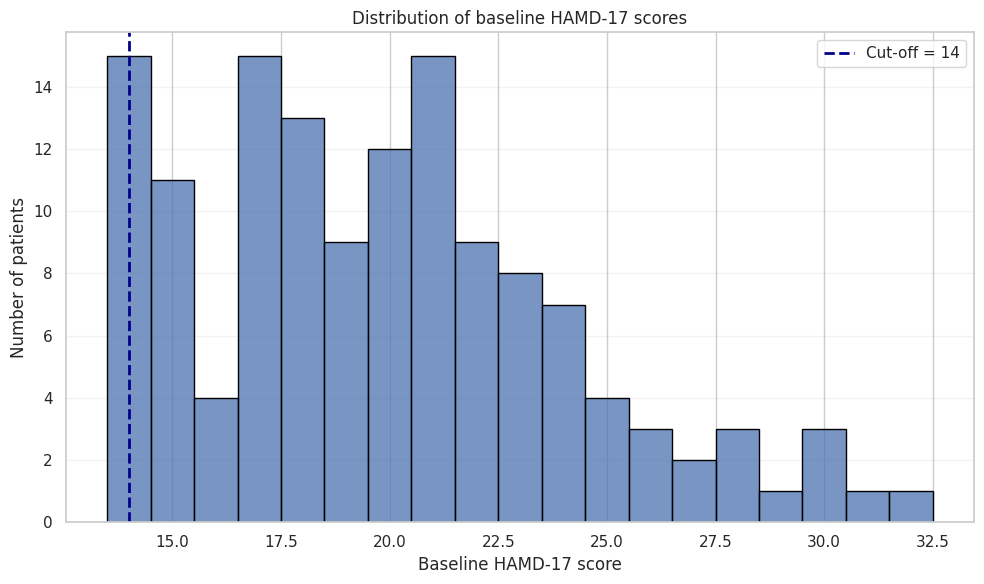

In [29]:
x = df_endpoint["BASVAL"].dropna()
bins = np.arange(x.min() - 0.5, x.max() + 1.5, 1)

# рисуем гистограмму
sns.histplot(
    x,
    bins=bins,
    stat="count",
    edgecolor="black",
    alpha=0.75,
)

#создаем вертикальную линию отсечки
plt.axvline(
    PRIMARY_BASELINE_CUTOFF,
    color="darkblue",
    linestyle="--",
    linewidth=2,
    label=f"Cut-off = {PRIMARY_BASELINE_CUTOFF}",
)


plt.grid(axis="y", alpha=0.25)

finalize_plot(
    title="Distribution of baseline HAMD-17 scores",
    xlabel="Baseline HAMD-17 score",
    ylabel="Number of patients",
    figsize=(10, 6),
    filename="01_baseline_hamd17_distribution.png"
)

Saved: reports/figures/02_endpoint_hamd17_distribution.png


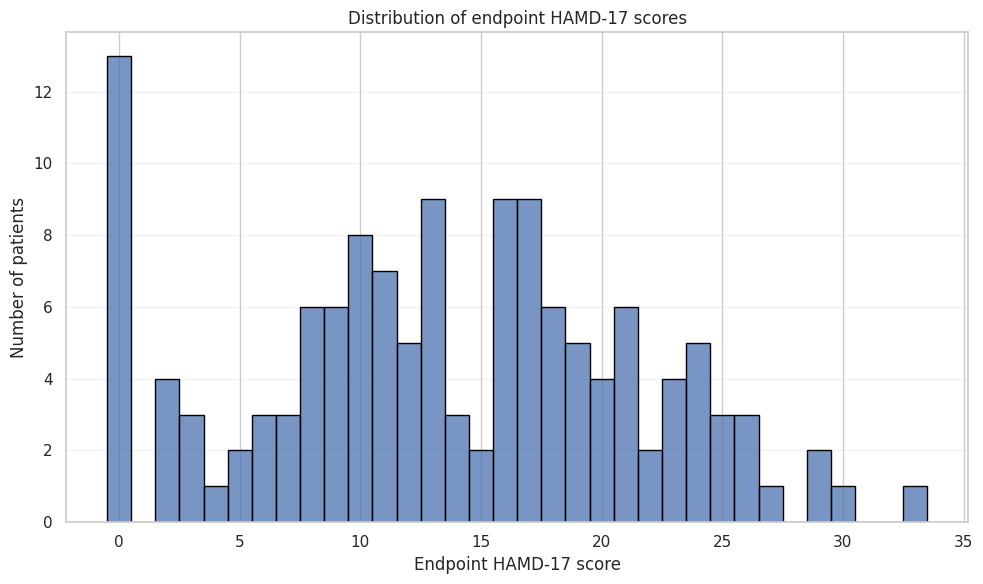

In [30]:
x = df_endpoint["HAMDTL17"].dropna()
bins = np.arange(x.min() - 0.5, x.max() + 1.5, 1)

# рисуем саму гистограмму
sns.histplot(
    x,
    bins=bins,
    stat="count",
    edgecolor="black",
    alpha=0.75,
)


plt.grid(axis="y", alpha=0.25)


finalize_plot(
    title="Distribution of endpoint HAMD-17 scores",
    xlabel="Endpoint HAMD-17 score",
    ylabel="Number of patients",
    figsize=(10, 6),
    filename="02_endpoint_hamd17_distribution.png"
)

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_endpoint["absolute_response"], bins=25, kde=True)
plt.title("Absolute response distribution")
plt.xlabel("Absolute response = baseline HAMD17 - endpoint HAMD17")
plt.ylabel("Number of patients")
save_current_fig("03_absolute_response_distribution.png")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_endpoint["percentage_response"], bins="fd", kde=True)
plt.title("Percentage response distribution")
plt.xlabel("Percentage response")
plt.ylabel("Number of patients")
save_current_fig("04_percentage_response_distribution.png")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_endpoint, x="THERAPY", y="percentage_response")
plt.title("Percentage response by treatment group")
plt.xlabel("Treatment group")
plt.ylabel("Percentage response")
save_current_fig("05_percentage_response_by_treatment_boxplot.png")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df_endpoint, x="THERAPY", y="percentage_response", inner="quartile")
plt.title("Percentage response distribution by treatment group")
plt.xlabel("Treatment group")
plt.ylabel("Percentage response")
save_current_fig("06_percentage_response_by_treatment_violin.png")
plt.show()

In [ ]:
distribution_summary = pd.concat(
    [
        distribution_diagnostics(df_endpoint, "absolute_response"),
        distribution_diagnostics(df_endpoint, "percentage_response"),
    ],
    ignore_index=True,
)

display(distribution_summary)

distribution_summary.to_csv(
    RESULTS_DIR / "distribution_summary_primary_endpoint.csv",
    index=False,
)

## Вывод по EDA

Эффект лечения: В группе DRUG медианный отклик заметно выше, чем в PLACEBO, однако наблюдается сильный индивидуальный разброс (от ухудшения состояния до полной ремиссии).Форма распределений: Метрики отклика (absolute и percentage) не имеют критических аномалий (D'Agostino $p > 0.05$), но демонстрируют выраженные широкие хвосты.Итог: Высокая дисперсия отклика визуально подтверждает, что сравнения только средних значений недостаточно. Данные содержат гетерогенность, что полностью обосновывает дальнейшее применение FMM (для поиска подгрупп) и квантильной регрессии.

# 9. Диагностика `POOLINV` и investigator-level структуры

Этот раздел нужен для обоснования:

1. почему мы учитываем `POOLINV`;
2. почему MixedLM может не сойтись;
3. почему fallback через OLS + `C(POOLINV)` является разумным решением.

In [ ]:
poolinv_summary = poolinv_diagnostics(df_endpoint)

display(poolinv_summary)
display(poolinv_summary.describe(include="all").T)

poolinv_summary.to_csv(
    RESULTS_DIR / "poolinv_diagnostics.csv",
    index=False,
)

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(poolinv_summary["n"], bins=10)
plt.title("Number of patients per POOLINV group")
plt.xlabel("Patients per POOLINV")
plt.ylabel("Number of POOLINV groups")
save_current_fig("07_poolinv_group_sizes.png")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(poolinv_summary["drug_share"], bins=10)
plt.title("Treatment balance inside POOLINV groups")
plt.xlabel("Drug share within POOLINV")
plt.ylabel("Number of POOLINV groups")
save_current_fig("08_poolinv_treatment_balance.png")
plt.show()

## Вывод по `POOLINV`

ВТакая структура подтверждает, что POOLINV действительно отражает уровень отдельных исследовательских центров. Однако малый размер групп делает использование моделей со смешанными эффектами (random-intercept MixedLM) вычислительно нестабильным. Чтобы обойти эту проблему, в пайплайне предусмотрен запасной вариант — переход на спецификацию с фиксированными эффектами центров и робастными ошибками HC3: response ~ treatment + BASVAL_centered + gender_female + C(POOLINV).

Фактически, переменная POOLINV отлично справляется со своей задачей для регрессионной корректировки (adjustment), но размеры этих групп слишком малы, чтобы пытаться интерпретировать их как полноценные независимые исследования.

# 10. Модель 1: baseline / investigator adjustment

Задача этой модели — рассчитать скорректированные остатки (adjusted residuals).Мы выделяем ту часть индивидуального отклика, которая не зависит от факта лечения, исходной тяжести депрессии, пола пациента и эффекта конкретного медцентра (POOLINV). Полученные остатки затем передаются на вход модели FMM.

In [ ]:
adjustment_result, adjustment_data, adjustment_model_type = fit_adjustment_model(
    df_endpoint,
    target="percentage_response",
)

# Preserve primary percentage-response adjustment results.
# This avoids accidental overwriting later in sensitivity sections.
primary_adjustment_result_percentage = adjustment_result
primary_adjustment_data_percentage = adjustment_data.copy()
primary_adjustment_model_type_percentage = adjustment_model_type

print("Adjustment model type:", adjustment_model_type)
print(adjustment_result.summary())

In [ ]:
df_endpoint = add_model_residuals(
    data=df_endpoint,
    model_result=adjustment_result,
    model_data=adjustment_data,
    target="percentage_response",
    residual_col="adjusted_residual_percentage",
)

display(df_endpoint[["percentage_response", "adjusted_residual_percentage"]].head())

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_endpoint["adjusted_residual_percentage"].dropna(), bins=25, kde=True)
plt.title("Adjusted residual distribution: percentage response")
plt.xlabel("Adjusted residual")
plt.ylabel("Number of patients")
save_current_fig("09_adjusted_residual_distribution_percentage.png")
plt.show()

In [ ]:
sm.qqplot(df_endpoint["adjusted_residual_percentage"].dropna(), line="45")
plt.title("QQ-plot of adjusted residuals: percentage response")
save_current_fig("10_adjusted_residual_qqplot_percentage.png")
plt.show()

In [ ]:
residual_diagnostics = distribution_diagnostics(
    df_endpoint,
    "adjusted_residual_percentage",
)

display(residual_diagnostics)

residual_diagnostics.to_csv(
    RESULTS_DIR / "adjusted_residual_diagnostics_percentage.csv",
    index=False,
)

## Вывод по скоректированной модели

Остатки выглядят достаточно нормально, они центрированы около нуля, сильной асимметрии нет, тест нормальности не отвергает нормальность. Это важно.

# 11. Модель 2: Finite Mixture Models

одели конечных смесей позволяют проверить, можно ли представить распределение остатков как комбинацию нескольких нормальных компонент. В данной работе модель гауссовых смесей применяется к одномерным остаткам, а не к полному набору признаков пациента.
11.2. Обучение и выбор модели

Модель гауссовых смесей обучается с помощью EM-алгоритма. Чтобы снизить зависимость результата от локальных оптимумов, каждая модель-кандидат запускается из нескольких случайных начальных состояний. Для заданного числа компонент и типа ковариационной матрицы сохраняется то решение, которое показало максимальное значение логарифма правдоподобия среди всех успешных запусков.

После этого модели с разным количеством компонент (K) сравниваются по байесовскому информационному критерию (BIC). Меньшее значение этого критерия означает оптимальный баланс между качеством подгонки и сложностью алгоритма.

Дополнительно оцениваются:

    размер выделенных компонент;

    устойчивость выбора K с помощью метода бутстрапа;

    чувствительность результатов к изменению целевой метрики, выбору конечной точки исследования и порогу отсечения по исходному состоянию пациента.

In [ ]:
fmm_values = df_endpoint["adjusted_residual_percentage"].dropna().values

gmm_results_percentage = fit_gmm_grid(
    fmm_values,
    components=FMM_COMPONENTS,
    covariance_types=FMM_COVARIANCE_TYPES_MAIN,
    random_state=RANDOM_STATE,
    n_init=FMM_RANDOM_STARTS_MAIN,
)

display(gmm_results_percentage[GMM_DISPLAY_COLUMNS].head(10))

best_gmm_percentage = gmm_results_percentage.loc[0, "model"]

# Preserve primary percentage-response FMM results.
primary_gmm_results_percentage = gmm_results_percentage.copy()
primary_best_gmm_percentage = best_gmm_percentage

print("Best FMM by BIC:")
print("K:", gmm_results_percentage.loc[0, "n_components"])
print("Covariance:", gmm_results_percentage.loc[0, "covariance_type"])
print("BIC:", gmm_results_percentage.loc[0, "bic"])

gmm_results_percentage[["n_components", "covariance_type", "bic", "aic", "converged_runs", "best_seed"]].to_csv(
    RESULTS_DIR / "fmm_model_selection_percentage.csv",
    index=False,
)

In [ ]:
plot_fmm_model_selection(
    gmm_results_percentage,
    title="FMM model selection: percentage response residuals",
    filename="11_fmm_model_selection_percentage.png",
)

In [ ]:
gmm_summary_percentage = summarize_gmm_components(best_gmm_percentage)

# Preserve primary percentage-response component summary.
primary_gmm_summary_percentage = gmm_summary_percentage.copy()

display(gmm_summary_percentage)

gmm_summary_percentage.to_csv(
    RESULTS_DIR / "fmm_component_summary_percentage.csv",
    index=False,
)

In [ ]:
plot_gmm_density(
    values=fmm_values,
    model=best_gmm_percentage,
    title="FMM on adjusted residuals: percentage response",
    filename="12_fmm_density_percentage.png",
)

## 11.3. Проверка хвостов и выбросов

Если FMM выбирает дополнительную маленькую компоненту, нужно проверить, не создаётся ли она несколькими экстремальными наблюдениями.


In [ ]:
outlier_table = df_endpoint.sort_values("adjusted_residual_percentage").head(10)[
    [
        "PATIENT",
        "THERAPY",
        "GENDER",
        "POOLINV",
        "BASVAL",
        "HAMDTL17",
        "CHANGE",
        "absolute_response",
        "percentage_response",
        "adjusted_residual_percentage",
        "VISIT",
        "RELDAYS",
    ]
]

display(outlier_table)

outlier_table.to_csv(
    RESULTS_DIR / "lowest_adjusted_residuals_inspection.csv",
    index=False,
)

# 12. Валидация FMM через bootstrap

Бустреп здесь используется для проверки устойчивости выбора числа компонент. Если на разных бустрэп семплах выбираются разные К, то латентные подгруппы нельзя считать устойчивыми.

In [ ]:
fmm_bootstrap_percentage = bootstrap_fmm_stability(
    fmm_values,
    n_bootstrap=FMM_BOOTSTRAP_ITERATIONS,
    components=FMM_COMPONENTS,
    covariance_types=FMM_COVARIANCE_TYPES_BOOTSTRAP,
    random_state=RANDOM_STATE,
)

# Preserve primary percentage-response bootstrap results.
primary_fmm_bootstrap_percentage = fmm_bootstrap_percentage.copy()

display(fmm_bootstrap_percentage["selected_k"].value_counts(dropna=False).sort_index())

print("Total bootstrap time, sec:", round(fmm_bootstrap_percentage["elapsed_total_sec"].iloc[0], 2))
print("Time per iteration, sec:", round(fmm_bootstrap_percentage["elapsed_per_iteration_sec"].iloc[0], 3))

fmm_bootstrap_percentage.to_csv(
    RESULTS_DIR / "fmm_bootstrap_stability_percentage.csv",
    index=False,
)

In [ ]:
plot_bootstrap_selected_k(
    fmm_bootstrap_percentage,
    title=f"FMM bootstrap stability: percentage response, n={FMM_BOOTSTRAP_ITERATIONS}",
    filename="13_fmm_bootstrap_selected_k_percentage.png",
)

## Вывод по FMM validation
В первичном анализе по BIC лучшая модель была с 1м компонентом,на бустреп сэмплах тоже значение выбиралось наиболее часто-136 против 8 для 2х компонент и 2 для 3х и 4х компонент.Дополнительные компоненты практически никогда не выбираются, из чего можно сделать вывод об устройчиости К=1.
Добавление дополнительных компонент увеличивало BIC, то есть не давало достаточного улучшения качества подгонки с учётом штрафа за сложность. Бутстреп-анализ подтвердил устойчивость результата: модель с одной компонентой выбиралась в 138 из 150 итераций.

FMM не выявила устойчивой многокомпонентной структуры.

# 13. Модель 3: Quantile regression


Квантильная регрессия оценивает ответ не в среднем, а на разных квантилях распределения ответа.

Первичная модель:


Так как у нас исследования индивидуальными данными пациентов, включение ковариат является преимуществом.

In [ ]:
qr_formula_percentage = "percentage_response ~ treatment + BASVAL_centered + gender_female"

qr_results_percentage = fit_quantile_regression_formula(
    data=df_endpoint,
    formula=qr_formula_percentage,
    target="percentage_response",
    quantiles=QUANTILES,
    model_name="baseline_gender",
)

# Preserve primary percentage-response QR results.
primary_qr_results_percentage = qr_results_percentage.copy()

display(qr_results_percentage)

qr_results_percentage.to_csv(
    RESULTS_DIR / "quantile_regression_percentage_primary.csv",
    index=False,
)

In [ ]:
plot_quantile_regression_results(
    qr_results_percentage,
    title="Quantile regression: treatment effect across percentage response",
    filename="14_quantile_regression_percentage_primary.png",
)

## 13.2. Goodness-of-fit для quantile regression

У quantile regression нет обычного OLS R². Поэтому используются:

- **pinball loss** — основная loss-функция quantile regression;
- **pseudo R²** — относительная мера качества;
- **stability of treatment coefficient** — устойчивость профиля treatment effect при добавлении ковариат.

Сравниваются три спецификации:

1. `treatment_only`;
2. `baseline_gender`;
3. `baseline_gender_poolinv`.

In [ ]:
qr_model_specs_percentage = {
    "treatment_only": "percentage_response ~ treatment",
    "baseline_gender": "percentage_response ~ treatment + BASVAL_centered + gender_female",
    "baseline_gender_poolinv": (
        "percentage_response ~ treatment + BASVAL_centered + gender_female + C(POOLINV)"
    ),
}

qr_comparison_percentage = []

for model_name, formula in qr_model_specs_percentage.items():
    qr_comparison_percentage.append(
        fit_quantile_regression_formula(
            data=df_endpoint,
            formula=formula,
            target="percentage_response",
            quantiles=QUANTILES,
            model_name=model_name,
        )
    )

qr_comparison_percentage = pd.concat(qr_comparison_percentage, ignore_index=True)

display(qr_comparison_percentage)

qr_comparison_percentage.to_csv(
    RESULTS_DIR / "quantile_regression_model_comparison_percentage.csv",
    index=False,
)

In [ ]:
plot_qr_model_comparison(
    qr_comparison_percentage,
    title="QR model comparison: treatment coefficient",
    filename="15_qr_comparison_treatment_coef_percentage.png",
    y_col="treatment_coef",
    y_label="Treatment coefficient",
)

plot_qr_model_comparison(
    qr_comparison_percentage,
    title="QR goodness-of-fit: pinball loss",
    filename="16_qr_comparison_pinball_loss_percentage.png",
    y_col="pinball_loss",
    y_label="Pinball loss",
)

plot_qr_model_comparison(
    qr_comparison_percentage,
    title="QR goodness-of-fit: pseudo R²",
    filename="17_qr_comparison_pseudo_r2_percentage.png",
    y_col="pseudo_r2",
    y_label="Pseudo R²",
)

## Вывод по quantile regression

Квантильная регрессия показала, что эффект лечения различается у пациентов с разной силой улучшения. У пациентов с небольшим улучшением разница между препаратом и плацебо маленькая. У пациентов со средним и достаточно сильным улучшением эта разница больше. На самых крайних участках распределения выводы менее надёжны, потому что там меньше наблюдений и интервалы неопределённости шире.

Дополнительная проверка показала, что учёт POOLINV улучшает описание данных: модель даёт меньшую ошибку и лучше объясняет различия в отклике. Это значит, что группа исследователя или центра действительно связана с тем, как распределяется ответ пациентов.

Общий вывод такой: пациенты отвечают на лечение по-разному, но это не обязательно означает, что они делятся на несколько чётких скрытых групп. Вместе с результатами FMM это даёт такую картину: устойчивых отдельных групп ответа мы не нашли, но различия в силе улучшения между пациентами есть.

# 14. Sensitivity analysis (Анализ чувствительности)

В этом проекте sensitivity analysis проверяет устойчивость результатов к нескольким решениям:

1. смена таргета: `percentage_response` → `absolute_response`;
2. смена endpoint: `last_available` → `VISIT == 7`;
3. смена baseline threshold: no cut-off, 14, 18, 20, 24;
4. сравнение FMM и quantile regression в разных сценариях;
5. spline sensitivity для baseline severity;
6. ANCOVA-style endpoint model как дополнительная проверка change-from-baseline результата.

## 14.1. Sensitivity target: absolute response

In [ ]:
absolute_adjustment_result, absolute_adjustment_data, absolute_model_type = fit_adjustment_model(
    df_endpoint,
    target="absolute_response",
)

print("Adjustment model type:", absolute_model_type)
print(absolute_adjustment_result.summary())

In [ ]:
df_endpoint = add_model_residuals(
    data=df_endpoint,
    model_result=absolute_adjustment_result,
    model_data=absolute_adjustment_data,
    target="absolute_response",
    residual_col="adjusted_residual_absolute",
)

In [ ]:
absolute_fmm_values = df_endpoint["adjusted_residual_absolute"].dropna().values

gmm_results_absolute = fit_gmm_grid(
    absolute_fmm_values,
    components=FMM_COMPONENTS,
    covariance_types=FMM_COVARIANCE_TYPES_MAIN,
    random_state=RANDOM_STATE,
    n_init=FMM_RANDOM_STARTS_MAIN,
)

display(gmm_results_absolute[GMM_DISPLAY_COLUMNS].head(10))

best_gmm_absolute = gmm_results_absolute.loc[0, "model"]
gmm_summary_absolute = summarize_gmm_components(best_gmm_absolute)

# Preserve absolute-response FMM results.
primary_gmm_results_absolute = gmm_results_absolute.copy()
primary_best_gmm_absolute = best_gmm_absolute
primary_gmm_summary_absolute = gmm_summary_absolute.copy()

display(gmm_summary_absolute)

gmm_results_absolute[["n_components", "covariance_type", "bic", "aic", "converged_runs", "best_seed"]].to_csv(
    RESULTS_DIR / "fmm_model_selection_absolute.csv",
    index=False,
)

gmm_summary_absolute.to_csv(
    RESULTS_DIR / "fmm_component_summary_absolute.csv",
    index=False,
)

In [ ]:
plot_fmm_model_selection(
    gmm_results_absolute,
    title="FMM model selection: absolute response residuals",
    filename="18_fmm_model_selection_absolute.png",
)

plot_gmm_density(
    values=absolute_fmm_values,
    model=best_gmm_absolute,
    title="FMM on adjusted residuals: absolute response",
    filename="19_fmm_density_absolute.png",
)

In [ ]:
fmm_bootstrap_absolute = bootstrap_fmm_stability(
    absolute_fmm_values,
    n_bootstrap=FMM_BOOTSTRAP_ITERATIONS,
    components=FMM_COMPONENTS,
    covariance_types=FMM_COVARIANCE_TYPES_BOOTSTRAP,
    random_state=RANDOM_STATE,
)

# Preserve absolute-response bootstrap results.
primary_fmm_bootstrap_absolute = fmm_bootstrap_absolute.copy()

display(fmm_bootstrap_absolute["selected_k"].value_counts(dropna=False).sort_index())

print("Total bootstrap time, sec:", round(fmm_bootstrap_absolute["elapsed_total_sec"].iloc[0], 2))
print("Time per iteration, sec:", round(fmm_bootstrap_absolute["elapsed_per_iteration_sec"].iloc[0], 3))

fmm_bootstrap_absolute.to_csv(
    RESULTS_DIR / "fmm_bootstrap_stability_absolute.csv",
    index=False,
)

In [ ]:
plot_bootstrap_selected_k(
    fmm_bootstrap_absolute,
    title=f"FMM bootstrap stability: absolute response, n={FMM_BOOTSTRAP_ITERATIONS}",
    filename="20_fmm_bootstrap_selected_k_absolute.png",
)

In [ ]:
qr_formula_absolute = "absolute_response ~ treatment + BASVAL_centered + gender_female"

qr_results_absolute = fit_quantile_regression_formula(
    data=df_endpoint,
    formula=qr_formula_absolute,
    target="absolute_response",
    quantiles=QUANTILES,
    model_name="baseline_gender",
)

# Preserve absolute-response QR results.
primary_qr_results_absolute = qr_results_absolute.copy()

display(qr_results_absolute)

qr_results_absolute.to_csv(
    RESULTS_DIR / "quantile_regression_absolute_primary.csv",
    index=False,
)

plot_quantile_regression_results(
    qr_results_absolute,
    title="Quantile regression: treatment effect across absolute response",
    filename="21_quantile_regression_absolute_primary.png",
)

In [ ]:
qr_model_specs_absolute = {
    "treatment_only": "absolute_response ~ treatment",
    "baseline_gender": "absolute_response ~ treatment + BASVAL_centered + gender_female",
    "baseline_gender_poolinv": (
        "absolute_response ~ treatment + BASVAL_centered + gender_female + C(POOLINV)"
    ),
}

qr_comparison_absolute = []

for model_name, formula in qr_model_specs_absolute.items():
    qr_comparison_absolute.append(
        fit_quantile_regression_formula(
            data=df_endpoint,
            formula=formula,
            target="absolute_response",
            quantiles=QUANTILES,
            model_name=model_name,
        )
    )

qr_comparison_absolute = pd.concat(qr_comparison_absolute, ignore_index=True)

display(qr_comparison_absolute)

qr_comparison_absolute.to_csv(
    RESULTS_DIR / "quantile_regression_model_comparison_absolute.csv",
    index=False,
)

In [ ]:
plot_qr_model_comparison(
    qr_comparison_absolute,
    title="QR model comparison: absolute response treatment coefficient",
    filename="22_qr_comparison_treatment_coef_absolute.png",
    y_col="treatment_coef",
    y_label="Treatment coefficient",
)

plot_qr_model_comparison(
    qr_comparison_absolute,
    title="QR goodness-of-fit: absolute response pinball loss",
    filename="23_qr_comparison_pinball_loss_absolute.png",
    y_col="pinball_loss",
    y_label="Pinball loss",
)

## 14.2. Sensitivity по endpoint и baseline threshold

In [ ]:
sensitivity_percentage_rows = []

for endpoint_name in ["last_available", "visit7"]:
    for cutoff in SENSITIVITY_CUTOFFS:
        sensitivity_percentage_rows.append(
            run_short_pipeline_summary(
                data=df,
                endpoint=endpoint_name,
                baseline_cutoff=cutoff,
                target="percentage_response",
            )
        )

sensitivity_percentage = pd.DataFrame(sensitivity_percentage_rows)

display(sensitivity_percentage)

sensitivity_percentage.to_csv(
    RESULTS_DIR / "sensitivity_summary_percentage.csv",
    index=False,
)

In [ ]:
sensitivity_absolute_rows = []

for endpoint_name in ["last_available", "visit7"]:
    for cutoff in SENSITIVITY_CUTOFFS:
        sensitivity_absolute_rows.append(
            run_short_pipeline_summary(
                data=df,
                endpoint=endpoint_name,
                baseline_cutoff=cutoff,
                target="absolute_response",
            )
        )

sensitivity_absolute = pd.DataFrame(sensitivity_absolute_rows)

display(sensitivity_absolute)

sensitivity_absolute.to_csv(
    RESULTS_DIR / "sensitivity_summary_absolute.csv",
    index=False,
)

In [ ]:
print("Percentage response sensitivity pivot:")
display(
    sensitivity_percentage.pivot_table(
        index=["endpoint", "baseline_cutoff"],
        values=["n", "best_fmm_k", "smallest_component_weight_pct", "qr_median_treatment_coef"],
        aggfunc="first",
    )
)

print("Absolute response sensitivity pivot:")
display(
    sensitivity_absolute.pivot_table(
        index=["endpoint", "baseline_cutoff"],
        values=["n", "best_fmm_k", "smallest_component_weight_pct", "qr_median_treatment_coef"],
        aggfunc="first",
    )
)

## 14.3. Sensitivity: spline baseline adjustment и ANCOVA-style endpoint model

В Stone et al. использовались multivariable adaptive regression splines для учета нелинейных эффектов
continuous covariates. В этой работе primary analysis намеренно проще из-за малого размера выборки,
но добавляется sensitivity check со spline-преобразованием `BASVAL_centered`.

Этот раздел отвечает на два вопроса:

1. Сильно ли меняется treatment coefficient, если baseline severity входит нелинейно?
2. Сохраняется ли вывод, если моделировать не change/response, а endpoint HAMD-17 score
   в ANCOVA-style спецификации?

Важно: для endpoint HAMD-17 меньшие значения означают лучший исход, поэтому отрицательный coefficient
у `treatment` в ANCOVA-style модели соответствует лучшему endpoint score в DRUG group.

In [ ]:
linear_response_formula = (
    "percentage_response ~ treatment + BASVAL_centered + "
    "gender_female + C(POOLINV)"
)

spline_response_formula = (
    "percentage_response ~ treatment + "
    "bs(BASVAL_centered, df=3, degree=3) + "
    "gender_female + C(POOLINV)"
)

linear_response_model = smf.ols(
    formula=linear_response_formula,
    data=df_endpoint,
).fit(cov_type="HC3")

spline_response_model = smf.ols(
    formula=spline_response_formula,
    data=df_endpoint,
).fit(cov_type="HC3")


def extract_treatment_row(model_result, model_name: str) -> dict:
    """Extract treatment coefficient summary from a statsmodels result."""
    conf_int = model_result.conf_int()
    treatment_coef = model_result.params.get("treatment", np.nan)

    return {
        "model_name": model_name,
        "treatment_coef": treatment_coef,
        "ci_low": conf_int.loc["treatment", 0],
        "ci_high": conf_int.loc["treatment", 1],
        "p_value": model_result.pvalues.get("treatment", np.nan),
        "aic": model_result.aic,
        "bic": model_result.bic,
        "n": int(model_result.nobs),
    }


spline_adjustment_comparison = pd.DataFrame(
    [
        extract_treatment_row(linear_response_model, "linear_baseline_poolinv"),
        extract_treatment_row(spline_response_model, "spline_baseline_poolinv"),
    ]
)

display(spline_adjustment_comparison)

spline_adjustment_comparison.to_csv(
    RESULTS_DIR / "spline_adjustment_comparison_percentage.csv",
    index=False,
)

In [ ]:
qr_formula_spline_percentage = (
    "percentage_response ~ treatment + "
    "bs(BASVAL_centered, df=3, degree=3) + "
    "gender_female"
)

qr_results_spline_percentage = fit_quantile_regression_formula(
    data=df_endpoint,
    formula=qr_formula_spline_percentage,
    target="percentage_response",
    quantiles=QUANTILES,
    model_name="baseline_spline_gender",
)

qr_linear_vs_spline_percentage = pd.concat(
    [
        qr_results_percentage.assign(model_name="baseline_linear_gender"),
        qr_results_spline_percentage,
    ],
    ignore_index=True,
)

display(qr_results_spline_percentage)

qr_results_spline_percentage.to_csv(
    RESULTS_DIR / "quantile_regression_percentage_spline_sensitivity.csv",
    index=False,
)

qr_linear_vs_spline_percentage.to_csv(
    RESULTS_DIR / "quantile_regression_linear_vs_spline_percentage.csv",
    index=False,
)

In [ ]:
plot_qr_model_comparison(
    qr_linear_vs_spline_percentage,
    title="QR sensitivity: linear vs spline baseline adjustment",
    filename="24_qr_linear_vs_spline_treatment_coef_percentage.png",
    y_col="treatment_coef",
    y_label="Treatment coefficient",
)

plot_qr_model_comparison(
    qr_linear_vs_spline_percentage,
    title="QR sensitivity: linear vs spline pinball loss",
    filename="25_qr_linear_vs_spline_pinball_loss_percentage.png",
    y_col="pinball_loss",
    y_label="Pinball loss",
)

In [ ]:
endpoint_linear_formula = (
    "HAMDTL17 ~ treatment + BASVAL_centered + "
    "gender_female + C(POOLINV)"
)

endpoint_spline_formula = (
    "HAMDTL17 ~ treatment + "
    "bs(BASVAL_centered, df=3, degree=3) + "
    "gender_female + C(POOLINV)"
)

endpoint_linear_model = smf.ols(
    formula=endpoint_linear_formula,
    data=df_endpoint,
).fit(cov_type="HC3")

endpoint_spline_model = smf.ols(
    formula=endpoint_spline_formula,
    data=df_endpoint,
).fit(cov_type="HC3")

ancova_endpoint_comparison = pd.DataFrame(
    [
        extract_treatment_row(endpoint_linear_model, "endpoint_linear_baseline_poolinv"),
        extract_treatment_row(endpoint_spline_model, "endpoint_spline_baseline_poolinv"),
    ]
)

ancova_endpoint_comparison[
    "implied_hamd17_improvement_for_drug"
] = -ancova_endpoint_comparison["treatment_coef"]

display(ancova_endpoint_comparison)

ancova_endpoint_comparison.to_csv(
    RESULTS_DIR / "ancova_endpoint_sensitivity.csv",
    index=False,
)

### Интерпретация spline / ANCOVA sensitivity

Если treatment coefficient в linear и spline response models близок по знаку и масштабу,
значит основной вывод не является артефактом линейного задания baseline severity.

ANCOVA-style endpoint model проверяет ту же идею с другой стороны: вместо response/change
моделируется endpoint HAMD-17 score с учетом baseline severity и `POOLINV`.
В этой модели отрицательный coefficient у `treatment` означает более низкий endpoint HAMD-17
в DRUG group, то есть лучший клинический исход.

## Вывод по sensitivity analysis

Sensitivity analysis проверяет, меняется ли главный вывод при других аналитических решениях:

1. другой response target;
2. другой endpoint;
3. другой baseline threshold;
4. spline specification для baseline severity;
5. ANCOVA-style endpoint model.

Если вывод меняется только в отдельных малых или нестабильных сценариях, основной результат следует формулировать осторожно и не делать сильных утверждений о клинических фенотипах.

# 15. Итоговые результаты

Этот раздел автоматически собирает ключевые численные результаты в одну таблицу. Таблицу можно использовать для отчёта, README и презентации.

In [ ]:
median_qr_percentage = qr_results_percentage.loc[
    np.isclose(qr_results_percentage["quantile"], 0.5),
    "treatment_coef",
]

median_qr_absolute = qr_results_absolute.loc[
    np.isclose(qr_results_absolute["quantile"], 0.5),
    "treatment_coef",
]

median_qr_spline_percentage = qr_results_spline_percentage.loc[
    np.isclose(qr_results_spline_percentage["quantile"], 0.5),
    "treatment_coef",
]

linear_spline_delta = (
    spline_adjustment_comparison.loc[
        spline_adjustment_comparison["model_name"] == "spline_baseline_poolinv",
        "treatment_coef",
    ].iloc[0]
    - spline_adjustment_comparison.loc[
        spline_adjustment_comparison["model_name"] == "linear_baseline_poolinv",
        "treatment_coef",
    ].iloc[0]
)

endpoint_linear_benefit = ancova_endpoint_comparison.loc[
    ancova_endpoint_comparison["model_name"] == "endpoint_linear_baseline_poolinv",
    "implied_hamd17_improvement_for_drug",
].iloc[0]

endpoint_spline_benefit = ancova_endpoint_comparison.loc[
    ancova_endpoint_comparison["model_name"] == "endpoint_spline_baseline_poolinv",
    "implied_hamd17_improvement_for_drug",
].iloc[0]

main_summary = pd.DataFrame(
    [
        {
            "raw_rows": len(df),
            "unique_patients": df["PATIENT"].nunique(),
            "primary_endpoint": "last_available",
            "primary_baseline_cutoff": PRIMARY_BASELINE_CUTOFF,
            "primary_n": len(df_endpoint),
            "primary_n_drug": int((df_endpoint["THERAPY"] == "DRUG").sum()),
            "primary_n_placebo": int(
                (df_endpoint["THERAPY"] == "PLACEBO").sum()
            ),
            "adjustment_model_type": primary_adjustment_model_type_percentage,
            "adjustment_treatment_coef_percentage": (
                primary_adjustment_result_percentage.params.get("treatment", np.nan)
            ),
            "best_fmm_k_percentage": (
                primary_gmm_results_percentage.loc[0, "n_components"]
            ),
            "best_fmm_covariance_percentage": (
                primary_gmm_results_percentage.loc[0, "covariance_type"]
            ),
            "best_fmm_bic_percentage": (
                primary_gmm_results_percentage.loc[0, "bic"]
            ),
            "smallest_fmm_component_weight_pct_percentage": (
                primary_gmm_summary_percentage["weight_pct"].min()
            ),
            "fmm_bootstrap_percentage": format_bootstrap_distribution(
                primary_fmm_bootstrap_percentage
            ),
            "qr_median_treatment_coef_percentage": (
                median_qr_percentage.iloc[0]
                if len(median_qr_percentage)
                else np.nan
            ),
            "best_fmm_k_absolute": gmm_results_absolute.loc[0, "n_components"],
            "best_fmm_covariance_absolute": (
                gmm_results_absolute.loc[0, "covariance_type"]
            ),
            "best_fmm_bic_absolute": gmm_results_absolute.loc[0, "bic"],
            "smallest_fmm_component_weight_pct_absolute": (
                gmm_summary_absolute["weight_pct"].min()
            ),
            "fmm_bootstrap_absolute": format_bootstrap_distribution(
                fmm_bootstrap_absolute
            ),
            "qr_median_treatment_coef_absolute": (
                median_qr_absolute.iloc[0]
                if len(median_qr_absolute)
                else np.nan
            ),
            "qr_median_treatment_coef_spline_percentage": (
                median_qr_spline_percentage.iloc[0]
                if len(median_qr_spline_percentage)
                else np.nan
            ),
            "linear_vs_spline_adjustment_treatment_delta": linear_spline_delta,
            "ancova_endpoint_linear_hamd17_benefit": endpoint_linear_benefit,
            "ancova_endpoint_spline_hamd17_benefit": endpoint_spline_benefit,
            "bootstrap_iterations": FMM_BOOTSTRAP_ITERATIONS,
        }
    ]
)

display(main_summary)

main_summary.to_csv(
    RESULTS_DIR / "main_summary.csv",
    index=False,
)

In [ ]:
print("Сводка ключевых результатов")
print("=" * 80)

n_rows = len(df)
n_patients = df["PATIENT"].nunique()
n_primary = len(df_endpoint)

n_drug = (df_endpoint["THERAPY"] == "DRUG").sum()
n_placebo = (df_endpoint["THERAPY"] == "PLACEBO").sum()

print(f"Исходные данные: {n_rows} строк, {n_patients} уникальных пациентов.")
print(
    "Основной анализ: последний доступный визит, "
    f"BASVAL >= {PRIMARY_BASELINE_CUTOFF}."
)
print(f"Размер выборки: N = {n_primary} ({n_drug} DRUG, {n_placebo} PLACEBO).")
print(f"Модель предварительной поправки: {primary_adjustment_model_type_percentage}.")

print("\nМодель смеси для процентного отклика")
best_k_percentage = int(primary_gmm_results_percentage.loc[0, "n_components"])
best_bic_percentage = primary_gmm_results_percentage.loc[0, "bic"]

print(f"Лучшее число компонент по BIC: {best_k_percentage}")
print(f"BIC лучшей модели: {best_bic_percentage:.3f}")
print(
    "Устойчивость по бутстрэпу: "
    f"{format_bootstrap_distribution(primary_fmm_bootstrap_percentage)}"
)

print("\nМодель смеси для абсолютного отклика")
best_k_absolute = int(gmm_results_absolute.loc[0, "n_components"])
best_bic_absolute = gmm_results_absolute.loc[0, "bic"]

print(f"Лучшее число компонент по BIC: {best_k_absolute}")
print(f"BIC лучшей модели: {best_bic_absolute:.3f}")
print(
    "Устойчивость по бутстрэпу: "
    f"{format_bootstrap_distribution(fmm_bootstrap_absolute)}"
)

if len(median_qr_percentage) > 0:
    median_qr_pct = median_qr_percentage.iloc[0]
    print(
        "\nКвантильная регрессия, процентный отклик: "
        f"коэффициент лечения на медиане = {median_qr_pct:.4f}"
    )

if len(median_qr_absolute) > 0:
    median_qr_abs = median_qr_absolute.iloc[0]
    print(
        "Квантильная регрессия, абсолютный отклик: "
        f"коэффициент лечения на медиане = {median_qr_abs:.4f}"
    )

if len(median_qr_spline_percentage) > 0:
    median_qr_spline = median_qr_spline_percentage.iloc[0]
    print(
        "Квантильная регрессия со spline-поправкой: "
        f"коэффициент лечения на медиане = {median_qr_spline:.4f}"
    )

print("\nANCOVA-модели для endpoint HAMD-17")
print(
    "Линейная поправка на baseline: "
    f"{endpoint_linear_benefit:.3f} балла HAMD-17"
)
print(
    "Spline-поправка на baseline: "
    f"{endpoint_spline_benefit:.3f} балла HAMD-17"
)

print("\nИтоговая интерпретация")
print(
    "Для основного показателя отклика модель смеси чаще всего выбирает "
    "одну компоненту. Анализ абсолютного отклика даёт похожий результат."
)
print(
    "Квантильная регрессия показывает, что различие между DRUG и PLACEBO "
    "меняется в разных частях распределения отклика."
)
print(
    "В совокупности результаты не подтверждают устойчивое разделение "
    "пациентов на несколько скрытых групп ответа, но показывают различия "
    "в силе улучшения между пациентами."
)

После преобразования продольных данных в формат «один пациент — одна строка» и применения порога исходной тяжести BASVAL >= 14 в основной анализ вошло 136 пациентов: 70 в группе DRUG и 66 в группе PLACEBO.

Для предварительной поправки была использована смешанная линейная модель со случайным сдвигом по POOLINV. Модель учитывала группу лечения, исходную тяжесть депрессии и пол пациента. Коэффициент лечения для процентного отклика составил 0.137, то есть после учёта этих факторов группа DRUG в среднем имела примерно на 13.7 процентного пункта большее улучшение, чем группа PLACEBO.

Далее модель смеси нормальных распределений применялась к остаткам этой модели, то есть к той части индивидуального отклика, которая не объяснялась лечением, исходной тяжестью, полом и структурой POOLINV. Для основного показателя percentage_response лучшей по BIC оказалась модель с одной компонентой: K = 1. Это означает, что модель не нашла необходимости делить пациентов на несколько устойчивых скрытых групп ответа.

Проверка устойчивости через бутстрэп подтвердила этот результат: модель с одной компонентой выбиралась в 92% повторов. Модели с двумя, тремя и четырьмя компонентами выбирались значительно реже.

Квантильная регрессия показала другую сторону результата: различие между DRUG и PLACEBO меняется в разных частях распределения отклика. На медиане коэффициент лечения для процентного отклика составил примерно 0.215, то есть около 21.5 процентного пункта. Это говорит о том, что сила улучшения неодинакова у разных пациентов, даже если устойчивые скрытые группы не выделяются.

Анализ чувствительности на absolute_response в целом подтвердил основной вывод. При замене процентного отклика на изменение в баллах HAMD-17 лучшей по BIC снова оказалась модель с одной компонентой. В бутстрэпе одна компонента выбиралась в 82% повторов. Это показывает, что вывод об отсутствии устойчивого разделения на скрытые группы не является артефактом только одного способа расчёта отклика.

Итоговый вывод: в этом открытом датасете после учёта основных факторов модель смеси нормальных распределений не выявила устойчивого разделения пациентов на несколько скрытых групп ответа. При этом квантильная регрессия показывает, что сила отклика действительно различается между пациентами. Поэтому результаты скорее поддерживают осторожную интерпретацию: индивидуальная неоднородность отклика есть, но в этих данных она лучше описывается как различная степень улучшения, а не как несколько чётких типов пациентов.

Важно учитывать ограничения: работа основана на одном открытом датасете с небольшим числом пациентов, ограниченным набором ковариат и агрегированной группой DRUG. Поэтому результаты следует рассматривать как исследовательский Data Science pipeline, а не как клиническое доказательство наличия или отсутствия отдельных фенотипов ответа на антидепрессанты.

# 16. Общие выводы для отчёта

Этот раздел заполняется после финального запуска тетради.

В выводах нужно кратко зафиксировать:

1. сколько пациентов вошло в primary analysis;
2. какой treatment effect получился в adjustment model;
3. какое значение `K` выбрано FMM по BIC для `percentage_response`;
4. насколько устойчив этот выбор в bootstrap;
5. какой профиль treatment effect показывает quantile regression;
6. меняется ли вывод в sensitivity analysis.

Финальный вывод должен быть осторожным: в этой работе анализируется один открытый dataset, поэтому результаты являются исследовательским Data Science pipeline, а не клиническим доказательством.

# 17. Примечание об использовании инструментов

Тетрадь подготовлена в формате воспроизводимого анализа: данные загружаются программно, все этапы обработки и моделирования выполняются кодом, а результаты сохраняются в папку `reports/`.

Формулировки выводов рекомендуется обновить после финального запуска, чтобы они соответствовали фактическим значениям в output cells.

# 18. Сохранение результатов

В конце тетради сохраняются:

- обработанные таблицы;
- диагностические таблицы;
- результаты моделей;
- графики;
- архив `project_outputs.zip`.

Архив можно скачать из Colab и добавить в GitHub-репозиторий вместе с ноутбуком.

In [ ]:
df_endpoint.to_csv(RESULTS_DIR / "df_endpoint_primary.csv", index=False)
df_visit7.to_csv(RESULTS_DIR / "df_visit7_primary.csv", index=False)

readme_text = f"""# Final Data Science Project

## Topic
Analysis of heterogeneous antidepressant treatment response using individual participant data.

## Dataset
Open longitudinal clinical trial dataset from rbmi::antidepressant_data.

## Primary analysis
- Endpoint: last available visit
- Baseline threshold: BASVAL >= {PRIMARY_BASELINE_CUTOFF}
- Primary target: percentage_response
- Sensitivity target: absolute_response

## Scientific motivation
The project compares two interpretations from the antidepressant-response literature:
- FMM-style latent response components.
- Quantile-based continuous heterogeneity of response.

## Methods
- Data preprocessing
- Exploratory data analysis
- Investigator-level adjustment using POOLINV
- LMM-style adjustment model with fallback to OLS + POOLINV fixed effects + HC3
- Gaussian Mixture Models
- Quantile regression
- Bootstrap validation
- Sensitivity analysis by target, endpoint and baseline threshold
- Spline baseline sensitivity
- ANCOVA-style endpoint sensitivity

## Key limitation
This is a single-study IPD analysis, not a multi-study IPD meta-analysis.
"""

Path("README_project_summary.md").write_text(readme_text, encoding="utf-8")

!zip -r project_outputs.zip reports data README_project_summary.md > /dev/null

print("Saved:")
print("- reports/")
print("- data/")
print("- README_project_summary.md")
print("- project_outputs.zip")

In [ ]:
# Uncomment in Google Colab to download the archive:
# from google.colab import files
# files.download("project_outputs.zip")

# 19. Финальная проверка по методичке

| Блок | Выполнено |
|---|---|
| Постановка задачи | Да |
| Загрузка данных | Да |
| Обработка данных | Да |
| EDA | Да |
| Визуализации с подписями | Да |
| Обучение моделей | Да |
| Валидация моделей | Да |
| Sensitivity analysis | Да |
| Spline / ANCOVA robustness checks | Да |
| Получение результатов | Да |
| Интерпретация результатов | Да |
| Общие выводы | Да |
| Ограничения | Да |
| Дальнейшее развитие | Да |
| Материалы для защиты | Да |
| Сохранение результатов | Да |
| Структурированность кода | Да: функции, логические блоки, понятные имена |
| PEP8-oriented оформление | Да: snake_case, умеренная длина строк, без закомментированного мусора |

## Code quality note

Так как работа сдаётся в формате Jupyter Notebook / Google Colab, линтеры `flake8` и `pylint`
напрямую применяются не так удобно, как к `.py`-скриптам. Однако код организован в функции,
использует осмысленные имена переменных, единый стиль и не содержит неиспользуемых больших
фрагментов закомментированного кода.

Если потребуется дополнительная проверка в репозитории, можно использовать `nbqa`:

```bash
pip install nbqa flake8
nbqa flake8 final_project_colab_methodology_aligned_spline_sensitivity.ipynb --max-line-length=120
```